Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

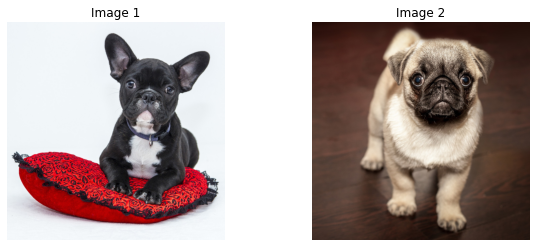

Cosine similarity (dog2 vs dog1): 0.3728


In [3]:
import torch
from transformers import ViTImageProcessor, ViTModel
from skimage.io import imread
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Carica modello (puoi usare anche facebook/dino-vits16)

model_name = "facebook/dino-vits16"

processor = ViTImageProcessor.from_pretrained(model_name)

# 1. Carica modello
model = ViTModel.from_pretrained(
    model_name,
    add_pooling_layer=False
).to(device)
model.eval()

# 2. Carica immagini
img1_np = imread("../img/dog2.jpg")
img2_np = imread("../img/dog1.jpg")

# Converti a PIL (più sicuro con HuggingFace)
img1 = Image.fromarray(img1_np.astype("uint8"))
img2 = Image.fromarray(img2_np.astype("uint8"))

# 3. Visualizza
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.axis("off")
plt.title("Image 1")

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.axis("off")
plt.title("Image 2")
plt.show()

# 4. Preprocessing corretto (batch di 2 immagini)
inputs = processor(images=[img1, img2], return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# 5. Estrai embedding CLS
with torch.no_grad():
    outputs = model(**inputs)
    cls_embeddings = outputs.last_hidden_state[:, 0]  # [2, hidden_dim]

# 6. Similarità coseno
sim = F.cosine_similarity(
    cls_embeddings[0].unsqueeze(0),
    cls_embeddings[1].unsqueeze(0)
).item()

print(f"Cosine similarity (dog2 vs dog1): {sim:.4f}")